In [1]:
from tqdm import tqdm
import treescope as ts
import matplotlib.pyplot as plt
import torch


class Logger(dict):
    def log(self, vals={}, *, pbar=None, prefix="", suffix="", **kwargs):
        vals = {**vals, **kwargs}
        for k, v in vals.items():
            self.setdefault(k, []).append(v)
        if pbar is not None:
            vals = {prefix + k + suffix: f"{v:.6f}" for k, v in vals.items()}
            pbar.set_postfix(**vals)

In [2]:
from data import DNADataset
dataset = DNADataset("hf://datasets/Zehui127127/latent-dna-diffusion/sequence.csv")

Loading data from hf://datasets/Zehui127127/latent-dna-diffusion/sequence.csv...
Processing data...
Done!


In [3]:
from vae import VQVAE

model = VQVAE(input_dim=5, cond_dim=0, encoded_dim=64, hidden_dim=128, fsq_levels=3)
ts.display(model)

In [ ]:
device = torch.device("cuda:2")
model = model.to(device=device)
model.train()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

logger = Logger()
epochs = 100
for j in range(epochs):
    for i, (X, y) in enumerate(pbar := tqdm(dataloader, desc=f"Epoch {j}")):
        X = X.to(device=device, non_blocking=True)
        y = y.to(device=device, non_blocking=True)
        loss, logs = model.train_step(X, c=None)
        logger.log(logs, pbar=pbar)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
            
    if (j+1) % 10 == 0:
        torch.save(model, f"ckpt/vqvae_epoch{j+1}.pth")

Epoch 23:  94%|█████████▍| 2341/2487 [09:09<00:34,  4.26it/s, loss_recon=0.531446]

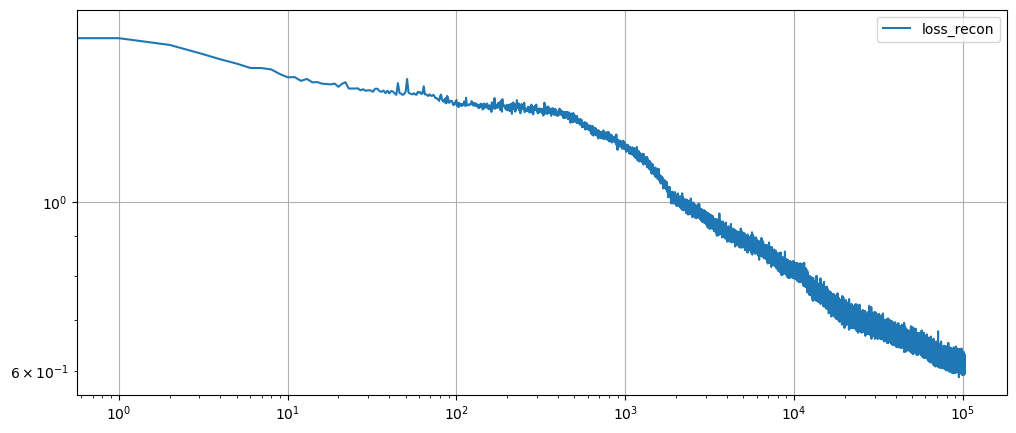

In [ ]:
plt.figure(figsize=(12, 5))
plt.semilogy(logger["loss_recon"], label="loss_recon")
plt.legend()
plt.grid()
plt.show()